In [1]:
# ── Imports
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import glob
import re
import json
import unicodedata
from pathlib import Path

import torch
from transformers import AutoProcessor, AutoModelForCausalLM

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Imports OK')
print(f'   torch   {torch.__version__}')
print(f'   device  {DEVICE}')
print(f'   CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

 Imports OK
   torch   2.10.0+cu128
   device  cpu
   CUDA available: False


In [2]:
CSV_PATH = Path('mumin_claims_cardio_diabete_baseline_ready.csv')
if not CSV_PATH.exists():
    raise FileNotFoundError(
        'Filtered dataset not found: mumin_claims_cardio_diabete_baseline_ready.csv\n'
        'Run NB1 first to generate it.'
    )

In [3]:
from huggingface_hub import login
login()

In [4]:
MODEL_ID = "google/gemma-3-4b-it"

processor = AutoProcessor.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype="auto",
    device_map="auto"
)
model.eval()

print(f' Gemma-3 loaded: {MODEL_ID}')
print(f'   Parameters : {sum(p.numel() for p in model.parameters()):,}')
tokenizer = processor.tokenizer if hasattr(processor, 'tokenizer') else processor

/home/diankham/anaconda3/lib/python3.13/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the disk and cpu.


 Gemma-3 loaded: google/gemma-3-4b-it
   Parameters : 4,300,079,472


In [5]:
def extract_gemma_embeddings(
    texts, processor, model, batch_size=1, max_length=512, pooling='last'
):
    """
    Extract fixed-size embeddings from a list of texts using Gemma-3.

    Args:
        texts      : list/array of raw strings to encode.
        processor  : HuggingFace AutoProcessor for Gemma-3.
        model      : HuggingFace AutoModelForCausalLM already loaded.
        batch_size : number of texts per forward pass (1–4 recommended for 4B).
        max_length : maximum number of tokens per text.
        pooling    : 'last' for last non-padding token, 'mean' for mean pooling.

    Returns:
        np.ndarray of shape (n_texts, hidden_size).
    """

    all_embeddings = []
    n = len(texts)

    # Use the tokenizer from the processor
    tok = processor.tokenizer if hasattr(processor, 'tokenizer') else processor

    print(f'Extracting {pooling}-pooled Gemma-3 embeddings ')
    print(f'   {n} texts | batch_size={batch_size} | max_length={max_length}')

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch = list(texts[start:end])

        # Tokenize the current batch
        encoded = tok(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )

       
        input_device = next(model.parameters()).device
        encoded = {k: v.to(input_device) for k, v in encoded.items()}

        with torch.no_grad():
            # output_hidden_states=True is required to get the hidden state matrix
            outputs = model(
                **encoded,
                output_hidden_states=True
            )

        last_hidden = outputs.hidden_states[-1]  

        attention_mask = encoded['attention_mask']  

        if pooling == 'last':
            # Index of the last non-padding token per sequence
            # attention_mask: 1 = real token, 0 = padding
            seq_lengths = attention_mask.sum(dim=1) - 1  # (batch,)
            batch_idx = torch.arange(last_hidden.size(0), device=last_hidden.device)
            embeddings = last_hidden[batch_idx, seq_lengths, :] 
            
        elif pooling == 'mean':
            # Mean over non-padding tokens
            mask = attention_mask.unsqueeze(-1).float()  # (batch, seq_len, 1)
            embeddings = (last_hidden * mask).sum(dim=1) / mask.sum(dim=1)  # (batch, hidden_size)

        else:
            raise ValueError(f'Unknown pooling: {pooling}. Choose "last" or "mean".')

        all_embeddings.append(embeddings.cpu().float().numpy())

        if (start // batch_size) % 10 == 0:
            print(f'   [{end}/{n}] done', end='\r')

    print(f'   [{n}/{n}] done        ')

    result = np.vstack(all_embeddings)
    print(f' Embedding matrix shape: {result.shape}')
    return result

In [6]:
df = pd.read_csv(CSV_PATH)
print(f'Loaded dataset with {len(df)} records')
print(f'Columns: {df.columns.tolist()}')
print(f'Class distribution:\n{df["label"].value_counts()}')

Loaded dataset with 354 records
Columns: ['text', 'label_name', 'label', 'verdict_norm']
Class distribution:
label
0    337
1     17
Name: count, dtype: int64


In [7]:
X = df['text']


In [8]:
# Embedding cache — avoid re-extracting every time
EMBEDDING_CACHE_PATH = 'gemma3_embeddings.npy'

if os.path.exists(EMBEDDING_CACHE_PATH):
    print(f'Loading cached embeddings from {EMBEDDING_CACHE_PATH} ...')
    X_embeddings = np.load(EMBEDDING_CACHE_PATH)
    print(f' Embeddings loaded: {X_embeddings.shape}')
else:
    print('No cached embeddings found, extracting from Gemma-3 — this may take a while... (30 mins expected)')
    X_embeddings = extract_gemma_embeddings(
        texts=X,
        processor=processor,
        model=model,
        batch_size=1,       
        max_length=512,
        pooling='last'     
    )
    np.save(EMBEDDING_CACHE_PATH, X_embeddings)
    print(f'Embeddings saved to cache: {EMBEDDING_CACHE_PATH}')

print('All steps completed successfully.')

Loading cached embeddings from gemma3_embeddings.npy ...
 Embeddings loaded: (354, 2560)
All steps completed successfully.


In [9]:
y = df['label'].values

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
print(' Split Train and Test')
print(f'  Train : {len(X_train)} articles  |  Fake: {(y_train==0).sum()}  Real: {(y_train==1).sum()}')
print(f'  Test  : {len(X_test)}  articles  |  Fake: {(y_test==0).sum()}  Real: {(y_test==1).sum()}')

 Split Train and Test
  Train : 283 articles  |  Fake: 269  Real: 14
  Test  : 71  articles  |  Fake: 68  Real: 3


In [11]:
# ── Classifiers on top of Gemma-3 embeddings

clf_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

clf_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LinearSVC(
        C=1.0,
        max_iter=2000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

clf_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation='relu',
        max_iter=300,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15
    ))
])

gemma_models = {
    'Gemma3 + LR':        clf_lr,
    'Gemma3 + LinearSVC': clf_svm,
    'Gemma3 + MLP':       clf_mlp,
}

for name in gemma_models:
    print(f'   • {name}')

   • Gemma3 + LR
   • Gemma3 + LinearSVC
   • Gemma3 + MLP


In [12]:
import joblib

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results_g4 = {}

for name, clf in gemma_models.items():
    cv = cross_validate(
        clf, X_embeddings, y,
        cv=SKF,
        scoring={
            'accuracy'        : 'accuracy',
            'f1_macro'        : 'f1_macro',
            'precision_macro' : 'precision_macro',
            'recall_macro'    : 'recall_macro',
        },
        return_train_score=False,
        n_jobs=-1
    )
    cv_results_g4[name] = cv
    joblib.dump(cv_results_g4, "cv_results_gemma.joblib")
    print(f'── {name} ──')
    print(f'  Accuracy  : {cv["test_accuracy"].mean():.4f} ± {cv["test_accuracy"].std():.4f}')
    print(f'  F1 macro  : {cv["test_f1_macro"].mean():.4f} ± {cv["test_f1_macro"].std():.4f}')
    print(f'  Precision : {cv["test_precision_macro"].mean():.4f} ± {cv["test_precision_macro"].std():.4f}')
    print(f'  Recall    : {cv["test_recall_macro"].mean():.4f} ± {cv["test_recall_macro"].std():.4f}')
    print()

── Gemma3 + LR ──
  Accuracy  : 0.9548 ± 0.0107
  F1 macro  : 0.6687 ± 0.1010
  Precision : 0.7493 ± 0.1642
  Recall    : 0.6357 ± 0.0822

── Gemma3 + LinearSVC ──
  Accuracy  : 0.9096 ± 0.0212
  F1 macro  : 0.6549 ± 0.0701
  Precision : 0.6226 ± 0.0538
  Recall    : 0.7310 ± 0.1050



/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


── Gemma3 + MLP ──
  Accuracy  : 0.9548 ± 0.0056
  F1 macro  : 0.5284 ± 0.0803
  Precision : 0.5773 ± 0.2006
  Recall    : 0.5250 ± 0.0500



/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/diankham/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [13]:
test_results_g4 = {}

for name, clf in gemma_models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    test_results_g4[name] = {
        'y_pred'    : y_pred,
        'accuracy'  : accuracy_score(y_test, y_pred),
        'prec_macro': precision_score(y_test, y_pred, average='macro'),
        'rec_macro' : recall_score(y_test, y_pred, average='macro'),
        'f1_macro'  : f1_score(y_test, y_pred, average='macro'),
        'f1_fake'   : f1_score(y_test, y_pred, pos_label=0),
        'f1_real'   : f1_score(y_test, y_pred, pos_label=1),
    }

    print(f'── {name} — Test Set ──')
    print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

── Gemma3 + LR — Test Set ──
              precision    recall  f1-score   support

        Fake       0.96      0.97      0.96        68
        Real       0.00      0.00      0.00         3

    accuracy                           0.93        71
   macro avg       0.48      0.49      0.48        71
weighted avg       0.92      0.93      0.92        71

── Gemma3 + LinearSVC — Test Set ──
              precision    recall  f1-score   support

        Fake       0.97      0.90      0.93        68
        Real       0.12      0.33      0.18         3

    accuracy                           0.87        71
   macro avg       0.55      0.62      0.56        71
weighted avg       0.93      0.87      0.90        71

── Gemma3 + MLP — Test Set ──
              precision    recall  f1-score   support

        Fake       0.96      0.94      0.95        68
        Real       0.00      0.00      0.00         3

    accuracy                           0.90        71
   macro avg       0.48      0.47

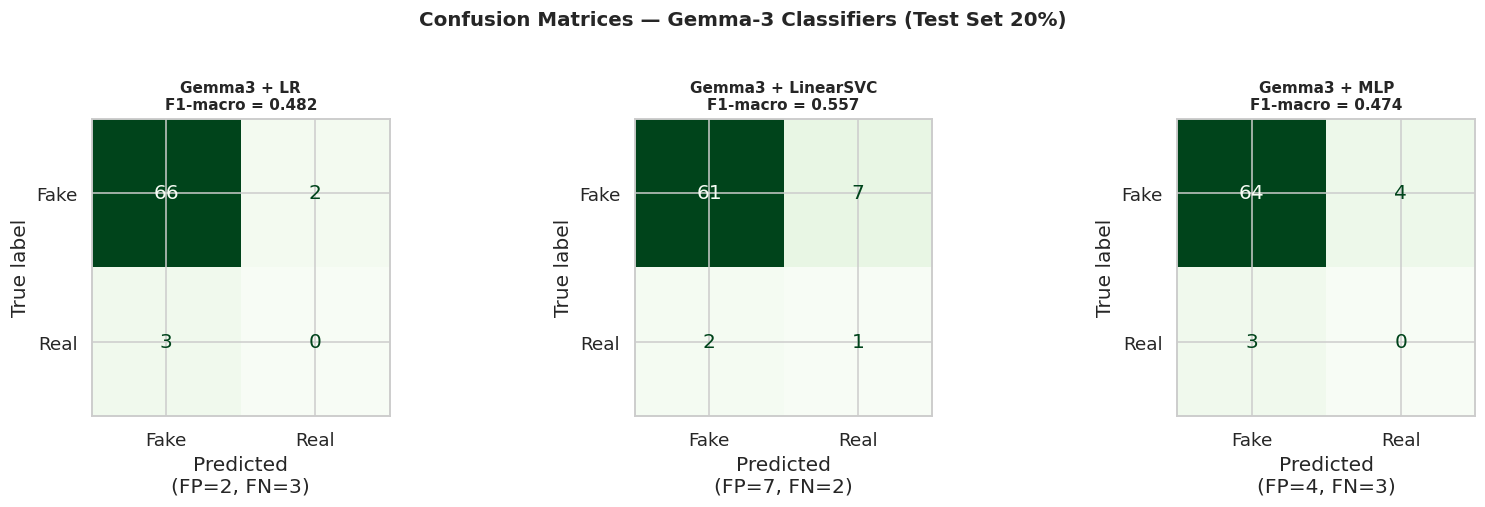

In [14]:
n_models = len(gemma_models)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, test_results_g4.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Fake', 'Real'])
    disp.plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(f'{name}\nF1-macro = {res["f1_macro"]:.3f}',
                 fontsize=10, fontweight='bold')
    fn = cm[1][0]
    fp = cm[0][1]
    ax.set_xlabel(f'Predicted\n(FP={fp}, FN={fn})')

plt.suptitle('Confusion Matrices — Gemma-3 Classifiers (Test Set 20%)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

plt.show()

In [15]:
print('=' * 100)

header = f'{"Modèle":<30} {"Acc":>7} {"Prec":>7} {"Recall":>7} {"F1-mac":>7} {"F1-Fake":>8} {"F1-Real":>8} {"CV F1±σ":>13}'
print(header)
print('-' * 100)

for name, res in test_results_g4.items():
    cv = cv_results_g4.get(name)
    if cv is not None and 'test_f1_macro' in cv:
        cv_f1_mean = cv['test_f1_macro'].mean()
        cv_f1_std  = cv['test_f1_macro'].std()
    else:
        cv_f1_mean = float('nan')
        cv_f1_std  = float('nan')

    row = (
        f'{name:<30} '
        f'{res["accuracy"]:>7.3f} '
        f'{res["prec_macro"]:>7.3f} '
        f'{res["rec_macro"]:>7.3f} '
        f'{res["f1_macro"]:>7.3f} '
        f'{res["f1_fake"]:>8.3f} '
        f'{res["f1_real"]:>8.3f} '
        f'{cv_f1_mean:>6.3f}±{cv_f1_std:.3f}'
    )
    print(row)

print('=' * 100)

Modèle                             Acc    Prec  Recall  F1-mac  F1-Fake  F1-Real       CV F1±σ
----------------------------------------------------------------------------------------------------
Gemma3 + LR                      0.930   0.478   0.485   0.482    0.964    0.000  0.669±0.101
Gemma3 + LinearSVC               0.873   0.547   0.615   0.557    0.931    0.182  0.655±0.070
Gemma3 + MLP                     0.901   0.478   0.471   0.474    0.948    0.000  0.528±0.080
